<a href="https://colab.research.google.com/github/ramalias/NDVI-practice/blob/main/ndvi-wildfire-changedetection-korea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[슬라이드] 코랩 실습: MODIS HDF 데이터 분석


1. 환경 설정 및 라이브러리 로드 코랩에서 HDF 파일을 다루기 위해 필요한 도구를 불러옴

Set up environment and load the library in Colab (to handle HDF file, get the necessary tools)

In [1]:
# import library

import numpy as np
from osgeo import gdal #reading and processing spatial data
import matplotlib.pyplot as plt

In [2]:
# HDF file path setup
file_before = '/content/drive/MyDrive/00_uni/2nd Semester/Remote Sensing Time Series Data Analysis/datasets/before_MOD13Q1.A2025097.h28v05.061.2025114003948.hdf'
file_after = '/content/drive/MyDrive/00_uni/2nd Semester/Remote Sensing Time Series Data Analysis/datasets/after_MOD13Q1.A2025129.h28v05.061.2025148084135.hdf'

2. HDF data handling

HDF 내부의 NDVI 레이어 추출 함수 HDF는 여러 층으로 구성되어 있으므로, 첫 번째 레이어인 NDVI만 콕 집어 가져와야 함


--> HDF consists of multiple layers, only extract the first layer which is NDVI layer


In [3]:
def get_ndvi_layer(file_path):
    dataset = gdal.Open(file_path)
    subdatasets = dataset.GetSubDatasets() #get subdatasets, because hdf contain numtible variable

    # 첫 번째 서브데이터셋(NDVI) 열기
    #open subdataset (first layer, usually ndvi [0][0] index)
    ndvi_ds = gdal.Open(subdatasets[0][0])
    ndvi_data = ndvi_ds.ReadAsArray().astype(np.float32) # read raster data as numpy array

    # MODIS Scale Factor(0.0001) 적용하여 실제 -1 ~ 1 범위로 변환
    ndvi_data *= 0.0001 #modis

    # 유효하지 않은 값(Fill Value) 처리 (보통 -0.3 이하의 낮은 값은 마스킹)
    # masking ndvi data --> choose greater that 0.2, but usually greater that 0.3
    ndvi_data[ndvi_data < -0.2] = np.nan
    return ndvi_data

# 데이터 불러오기
ndvi_apr = get_ndvi_layer(file_before)
ndvi_mei = get_ndvi_layer(file_after)


'''
NOTE:
- Extracts NDVI from a MODIS file
- Converts it into real NDVI value (range become -1 ~ 1) --> because of scale?
- Cleans invalid pixels
- Return usable Numpy array
'''


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


' \nNOTE: \n- Extracts NDVI from a MODIS file\n- Converts it into real NDVI value (range become -1 ~ 1) --> because of scale?\n- Cleans invalid pixels\n- Return usable Numpy array \n'

3. NDVI 차이 계산 및 시각화 두 시점의 차이를 구하고, 그 변화를 지도로 출력

NDVI difference calculation and visualization: calculate difference between 2 time point



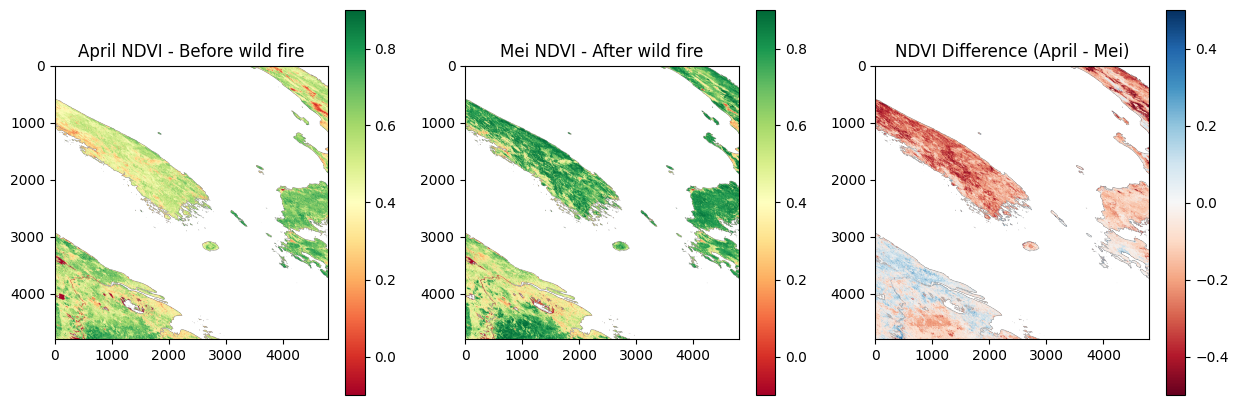

In [4]:
# NDVI 차이 계산 (나중 시기 - 이전 시기)
diff_ndvi = ndvi_apr - ndvi_mei

# 시각화 코드
plt.figure(figsize=(15, 5))

# 4월 NDVI (before)
plt.subplot(1, 3, 1)
plt.imshow(ndvi_apr, cmap='RdYlGn', vmin=-0.1, vmax=0.9)
plt.title('April NDVI - Before wild fire')
plt.colorbar()

# 5월 NDVI (after)
plt.subplot(1, 3, 2)
plt.imshow(ndvi_mei, cmap='RdYlGn', vmin=-0.1, vmax=0.9)
plt.title('Mei NDVI - After wild fire')
plt.colorbar()

# 차이 분석 (ΔNDVI) --> the difference
plt.subplot(1, 3, 3)
plt.imshow(diff_ndvi, cmap='RdBu', vmin=-0.5, vmax=0.5)
plt.title('NDVI Difference (April - Mei)')
plt.colorbar()

plt.show()

# GDAL WRAP

In [5]:
# 1. 좌표 보정 함수 (WGS84로 재투영)
def get_ndvi_corrected(file_path):
    # HDF 파일 열기
    ds = gdal.Open(file_path)
    if ds is None:
        print(f"파일을 찾을 수 없습니다: {file_path}")
        return None

    # 첫 번째 레이어(NDVI) 경로 추출
    sub = ds.GetSubDatasets()[0][0]

    # [핵심] gdal.Warp를 사용하여 EPSG:4326(표준 경위도 좌표계)으로 변환
    # dstSRS='EPSG:4326'이 찌그러진 영상을 똑바로 펴주는 역할을 함
    warped_ds = gdal.Warp('', sub, format='VRT', dstSRS='EPSG:4326')

    # 데이터를 배열로 읽고 실수형으로 변환
    data = warped_ds.ReadAsArray().astype(np.float32)

    # MODIS Scale Factor 적용 (0.0001) 및 유효값 처리
    data *= 0.0001
    data[data < -0.2] = np.nan # 결측치 및 수계 처리

    return data

In [6]:
# 2. 데이터 로드
ndvi_apr = get_ndvi_corrected(file_before)
ndvi_mei = get_ndvi_corrected(file_after)

# 3. NDVI 차이 계산
diff_ndvi = ndvi_apr - ndvi_mei

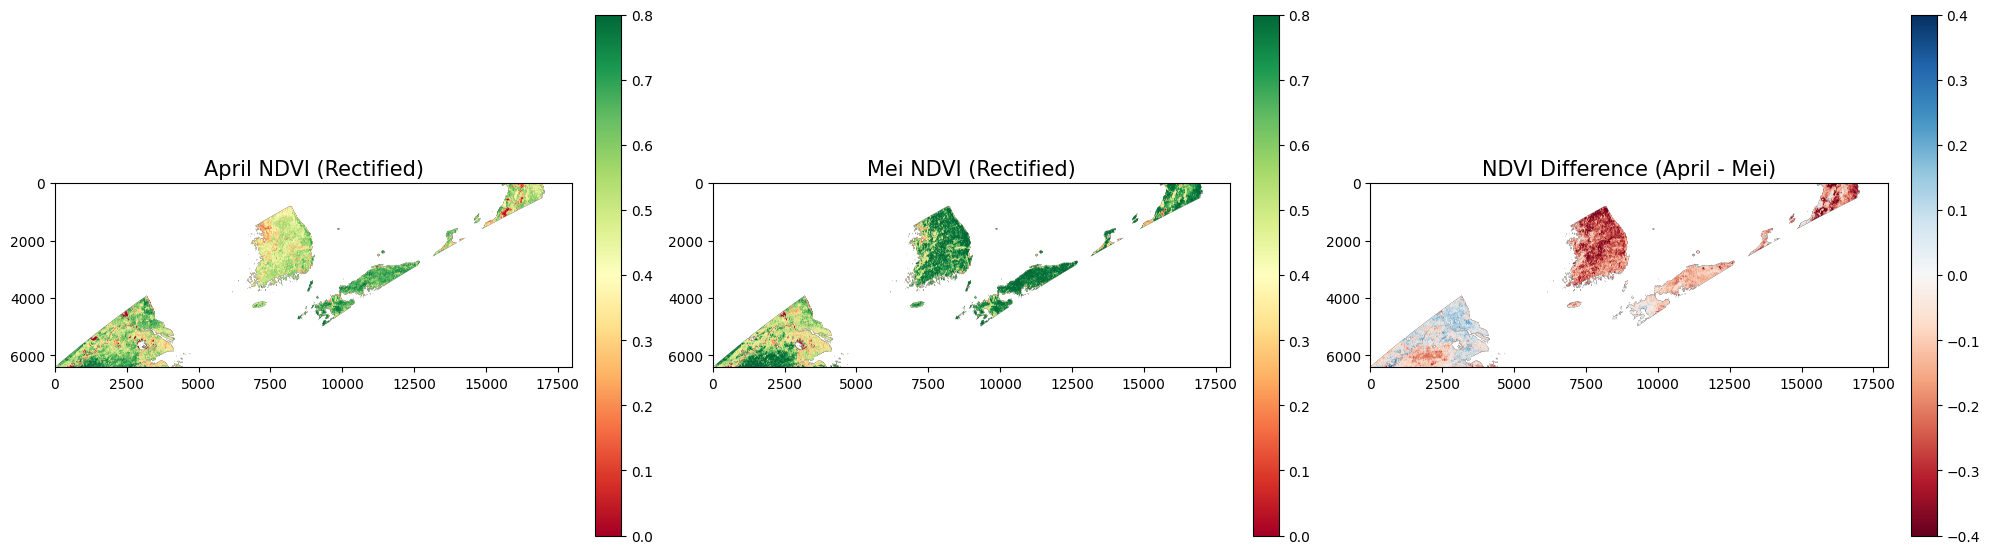

In [7]:
# 4. 시각화 (펴진 이미지 출력)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 설정: 색상 범위와 컬러맵
ndvi_opts = {'cmap': 'RdYlGn', 'vmin': 0, 'vmax': 0.8}
diff_opts = {'cmap': 'RdBu', 'vmin': -0.4, 'vmax': 0.4}

# 시각화 실행
im1 = axes[0].imshow(ndvi_apr, **ndvi_opts)
axes[0].set_title('April NDVI (Rectified)', fontsize=15) #제목 설정
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(ndvi_mei, **ndvi_opts)
axes[1].set_title('Mei NDVI (Rectified)', fontsize=15)
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

im3 = axes[2].imshow(diff_ndvi, **diff_opts)
axes[2].set_title('NDVI Difference (April - Mei)', fontsize=15)
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# 한반도 위경도 범위 설정 (Bounding Box)
# [최소경도, 최소위도, 최대경도, 최대위도]
korea_extent = [124.0, 33.0, 132.0, 43.0]

def get_korea_ndvi(file_path):
    ds = gdal.Open(file_path)
    sub = ds.GetSubDatasets()[0][0]

    # [핵심] outputBounds 설정을 추가하여 한반도 영역만 잘라서 가져옵니다.
    warped_ds = gdal.Warp('', sub, format='VRT',
                          dstSRS='EPSG:4326',
                          outputBounds=korea_extent)

    data = warped_ds.ReadAsArray().astype(np.float32)
    data *= 0.0001
    data[data < -0.2] = np.nan
    return data

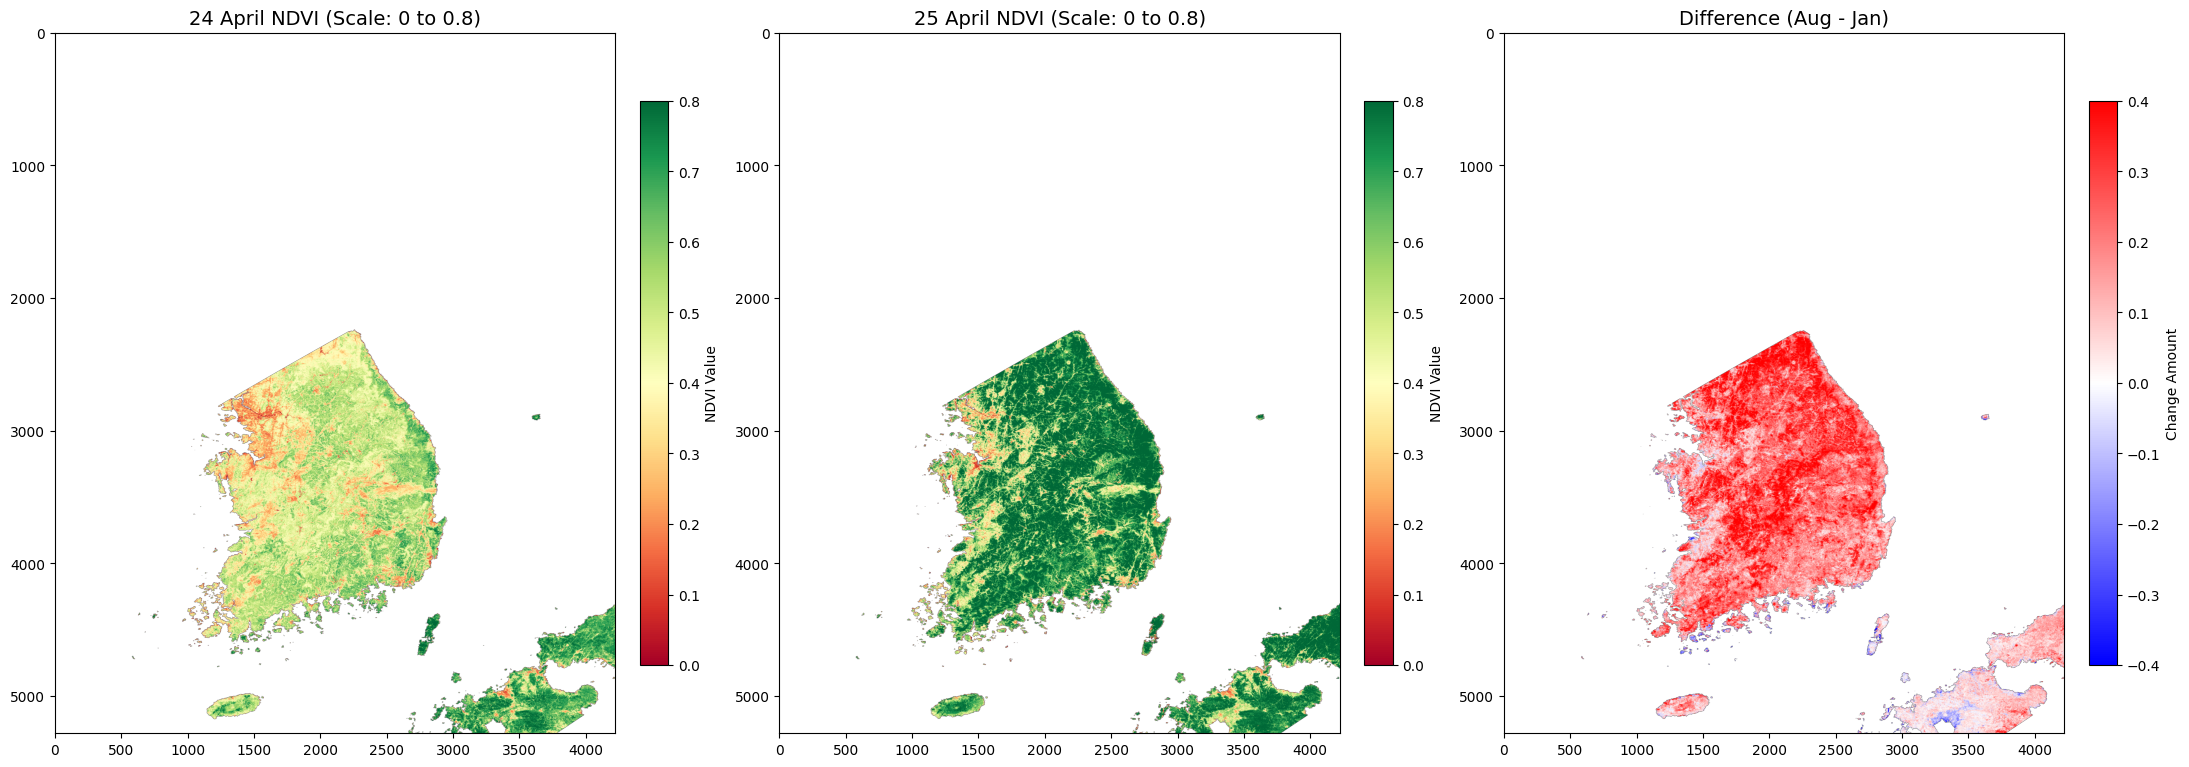

In [8]:
# 한반도 영역 데이터 로드
ndvi_jan_kor = get_korea_ndvi(file_before)
ndvi_aug_kor = get_korea_ndvi(file_after)
diff_kor = ndvi_aug_kor - ndvi_jan_kor

# 시각화 실행 (한반도 중심)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# 1. NDVI (1월, 8월) 설정
ndvi_opts = {'cmap': 'RdYlGn', 'vmin': 0, 'vmax': 0.8}
# 2. Difference (차이) 설정: -0.4 ~ 0.4 정도로 범위를 좁혀야 변화가 잘 보입니다.
diff_opts = {'cmap': 'bwr', 'vmin': -0.4, 'vmax': 0.4}

# 시각화 및 스케일바 추가
im1 = axes[0].imshow(ndvi_jan_kor, **ndvi_opts)
axes[0].set_title('24 April NDVI (Scale: 0 to 0.8)', fontsize=14)
fig.colorbar(im1, ax=axes[0], label='NDVI Value', fraction=0.046, pad=0.04)

im2 = axes[1].imshow(ndvi_aug_kor, **ndvi_opts)
axes[1].set_title('25 April NDVI (Scale: 0 to 0.8)', fontsize=14)
fig.colorbar(im2, ax=axes[1], label='NDVI Value', fraction=0.046, pad=0.04)

im3 = axes[2].imshow(diff_kor, **diff_opts)
axes[2].set_title('Difference (Aug - Jan)', fontsize=14)
fig.colorbar(im3, ax=axes[2], label='Change Amount', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()